# Khám Phá & Đánh Giá Chất Lượng Dữ Liệu (Data Quality EDA)
Notebook này được tinh chỉnh chuyên sâu để không chỉ xem tổng quan, mà còn **chuẩn bị nền tảng cho khâu Machine Learning/Data Pipeline phía sau**. Chúng ta sẽ phân tích kỹ về độ sạch của dữ liệu văn bản, giá trị dị biệt (outliers) của giá, và sự đồng nhất của hình ảnh để phục vụ Model Training.

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Thiết lập hiển thị đồ thị
%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.float_format', lambda x: '%.2f' % x)

## 1. Nạp Dữ Liệu & Gắn Flag Chất Lượng
Khi chuẩn bị Data cho Model, điều quan trọng nhất là **Dữ liệu có bị khuyết thiếu không?**. Ở bước này ta sẽ kiểm tra xem ảnh thực tế có lưu thành công trên ổ cứng hay không và gắn cờ `has_image`.

In [2]:
base_dir = "ssc_data_lake/bronze"
meta_dir = os.path.join(base_dir, "metadata")
img_dir = os.path.join(base_dir, "images")

data = []
if os.path.exists(meta_dir):
    for filename in os.listdir(meta_dir):
        if filename.endswith(".json"):
            filepath = os.path.join(meta_dir, filename)
            try:
                with open(filepath, 'r', encoding='utf-8') as f:
                    meta = json.load(f)
                    # KIỂM TRA CHẤT LƯỢNG: Ảnh có tồn tại không?
                    img_path = os.path.join(img_dir, f"{meta.get('product_id')}.jpg")
                    has_image = os.path.exists(img_path)
                    
                    flat_meta = {
                        "product_id": meta.get("product_id"),
                        "product_name": meta.get("product_name", ""),
                        "source": meta.get("source"),
                        "category_group": meta.get("category_group"),
                        "price": meta.get("attributes", {}).get("price", 0),
                        "has_image": has_image
                    }
                    data.append(flat_meta)
            except Exception as e:
                pass

df = pd.DataFrame(data)
print(f"-> Tổng số sản phẩm trong thư mục: {len(df)}")
df.head()

-> Tổng số sản phẩm trong thư mục: 45369


,product_id,product_name,source,category_group,price,has_image
0,BHX_100141780,[ORGANIC] Gạo Lứt Tím Hữu Cơ Hộp 1Kg - Gạo Hữu...,BachHoaXanh,Bách Hóa Online - Thực Phẩm,90000,True
1,BHX_101585635,Tấm Thơm ( Tấm Gạo ST25 ) Ông Thọ 1Kg - Cơm mề...,BachHoaXanh,Bách Hóa Online - Thực Phẩm,28000,True
2,BHX_102125498,HẠT BÍ TRẮNG TÂN LỘC PHÁT COMBO 1KG - MỖI BỊCH...,BachHoaXanh,Bách Hóa Online - Thực Phẩm,188500,True
3,BHX_10371298,Sữa bột Wincofood Bonecare Calcimax+ 850g dành...,BachHoaXanh,Bách Hóa Online - Thực Phẩm,389000,True
4,BHX_104366973,Siro GTP hương Kiwi/ Táo xanh/ Khoai môn,BachHoaXanh,Bách Hóa Online - Thực Phẩm,101000,True


## 2. Phân Tích Độ Sạch Của Dữ Liệu (Cleanliness Analysis)
Các mô hình Học Máy rất nhạy cảm với "rác". Chúng ta cần biết tỷ lệ dữ liệu lỗi (giá trị = 0, thiếu ảnh) để lên phương án lọc (Filter) ở khâu làm sạch dữ liệu (Silver Layer).

In [3]:
# 1. Đánh giá tỷ lệ mất mát hình ảnh
print("--- 1. TÌNH TRẠNG HÌNH ẢNH (Dành cho Computer Vision) ---")
display(df['has_image'].value_counts())
missing_img_percent = (len(df[df['has_image'] == False]) / len(df)) * 100
print(f"-> Cần loại bỏ {missing_img_percent:.2f}% dữ liệu do thiếu ảnh thực tế.\n")

# 2. Đánh giá tính logic của Giá
print("--- 2. TÌNH TRẠNG GIÁ SẢN PHẨM (Dành cho Data Analysis/Pricing Model) ---")
zero_price_count = (df['price'] <= 0).sum()
print(f"-> Số lượng sản phẩm có giá <= 0 (Sản phẩm ảo/Hết hàng): {zero_price_count} ({zero_price_count/len(df)*100:.2f}%)")

# 3. Đánh giá độ dài text 
df['name_length'] = df['product_name'].apply(len)
print("\n--- 3. ĐỘ DÀI TÊN SẢN PHẨM (Dành cho mô hình NLP) ---")
print(df['name_length'].describe())

--- 1. TÌNH TRẠNG HÌNH ẢNH (Dành cho Computer Vision) ---


has_image
True    45369
Name: count, dtype: int64

-> Cần loại bỏ 0.00% dữ liệu do thiếu ảnh thực tế.

--- 2. TÌNH TRẠNG GIÁ SẢN PHẨM (Dành cho Data Analysis/Pricing Model) ---
-> Số lượng sản phẩm có giá <= 0 (Sản phẩm ảo/Hết hàng): 0 (0.00%)

--- 3. ĐỘ DÀI TÊN SẢN PHẨM (Dành cho mô hình NLP) ---
count   45369.00
mean       69.19
std        32.45
min         4.00
25%        46.00
50%        63.00
75%        88.00
max       255.00
Name: name_length, dtype: float64


## 3. Xác định Giá Trị Dị Biệt (Outliers) bằng Boxplot
Thay vì Histogram, Boxplot giúp ta nhìn rõ những sản phẩm có giá cực kỳ cao (Outliers) so với mặt bằng chung. Khi train model dự đoán giá, những outliers này thường làm sai lệch độ chính xác và cần được xử lý riêng.

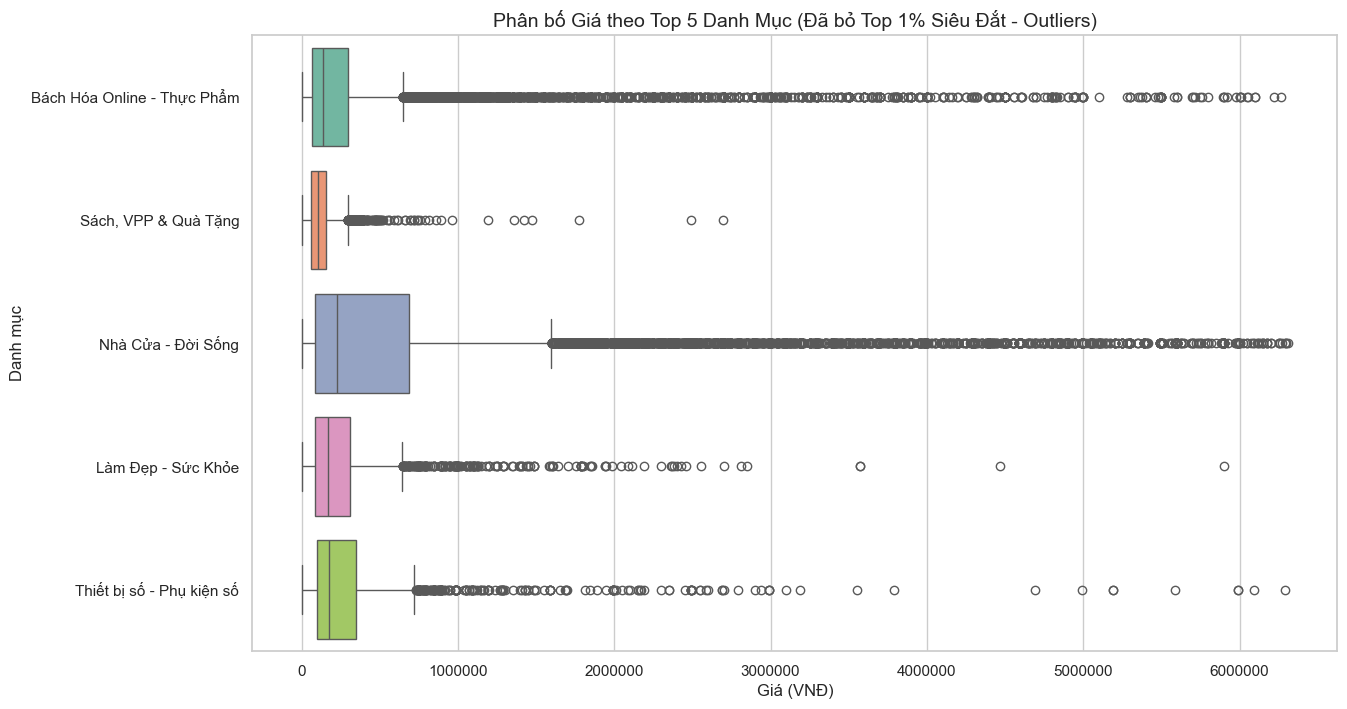

In [4]:
plt.figure(figsize=(14, 8))
# Chọn top 5 danh mục phổ biến nhất
top_5_cats = df['category_group'].value_counts().head(5).index
df_top5 = df[df['category_group'].isin(top_5_cats)]

# Loại bỏ Top 1% giá cao nhất để biểu đồ không bị bóp méo do 1 vài mặt hàng siêu đắt
q99 = df_top5['price'].quantile(0.99)
df_top5_filtered = df_top5[df_top5['price'] < q99]

sns.boxplot(data=df_top5_filtered, x='price', y='category_group', palette='Set2')
plt.title('Phân bố Giá theo Top 5 Danh Mục (Đã bỏ Top 1% Siêu Đắt - Outliers)', fontsize=14)
plt.xlabel('Giá (VNĐ)', fontsize=12)
plt.ylabel('Danh mục', fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.show()

## 4. Phân Tích Thuộc Tính Hình Ảnh (Cho Computer Vision Pipeline)
Để đưa vào các mạng Neural Networks (như ResNet, YOLO), các hình ảnh thường phải bị resize (Ví dụ: 224x224). Nếu tỷ lệ khung hình (Aspect Ratio) của các ảnh gốc dao động quá lớn, việc resize sẽ làm sản phẩm bị méo xệch. Chúng ta cần đo lường Aspect Ratio của tập dữ liệu.

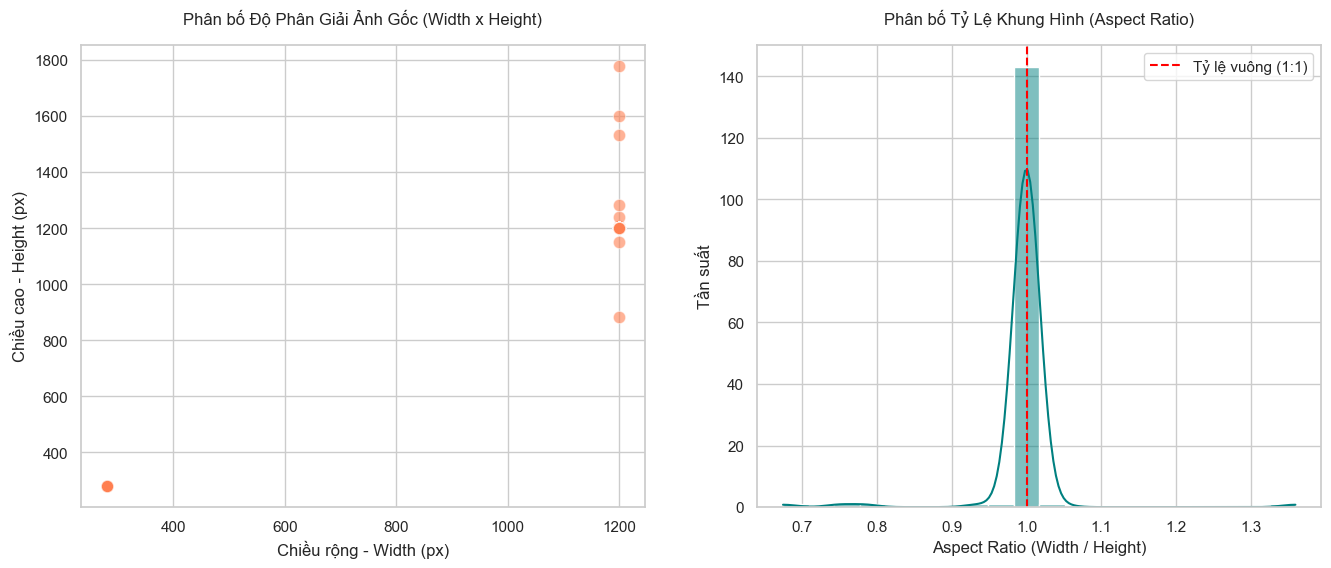

In [5]:
# Lấy ngẫu nhiên 150 ảnh hợp lệ để phân tích nhanh
sample_images = df[df['has_image'] == True].sample(min(150, len(df[df['has_image'] == True])))
image_sizes = []

for _, row in sample_images.iterrows():
    img_path = os.path.join(img_dir, f"{row['product_id']}.jpg")
    try:
        with Image.open(img_path) as img:
            image_sizes.append({
                'width': img.width,
                'height': img.height,
                'aspect_ratio': img.width / img.height
            })
    except Exception:
        pass

if image_sizes:
    df_sizes = pd.DataFrame(image_sizes)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Scatter plot cho Width vs Height
    sns.scatterplot(data=df_sizes, x='width', y='height', ax=ax1, alpha=0.6, color='coral', s=80)
    ax1.set_title('Phân bố Độ Phân Giải Ảnh Gốc (Width x Height)', pad=15)
    ax1.set_xlabel('Chiều rộng - Width (px)')
    ax1.set_ylabel('Chiều cao - Height (px)')
    
    # Histogram cho Aspect Ratio
    sns.histplot(data=df_sizes, x='aspect_ratio', bins=20, kde=True, ax=ax2, color='teal')
    ax2.axvline(1.0, color='red', linestyle='--', label='Tỷ lệ vuông (1:1)')
    ax2.set_title('Phân bố Tỷ Lệ Khung Hình (Aspect Ratio)', pad=15)
    ax2.set_xlabel('Aspect Ratio (Width / Height)')
    ax2.set_ylabel('Tần suất')
    ax2.legend()
    
    plt.show()
else:
    print("Không có hình ảnh để phân tích.")

## 5. Kết Luận & Check-list cho Bước Xử Lý Tiếp Theo (Data Pipeline)
Dựa trên các phân tích trên, khi đẩy dữ liệu này vào Pipeline tiền xử lý (chuyển sang Silver Data Lake) hoặc đưa vào Model, chúng ta bắt buộc phải cấu hình các bộ lọc sau:

1. **Image Validation**: Xóa bỏ hoàn toàn các record có `has_image == False` để tránh lỗi I/O khi train model.
2. **Price Logic**: Lọc bỏ các sản phẩm có `price <= 0` vì đây là nhiễu.
3. **Text Normalization**: Do chiều dài tên sản phẩm có sự chênh lệch lớn, cần cấu hình độ dài tối đa (Max Length / Padding) khi đưa vào mô hình NLP/Tokenizers.
4. **Image Preprocessing**: Dựa vào Aspect Ratio, nếu ảnh không hoàn toàn là hình vuông (1:1), nên dùng kỹ thuật **Letterbox Padding** (chèn viền đen/trắng) trước khi Resize để tránh làm biến dạng sản phẩm.